In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Visualization defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# Load standard California Housing dataset from Scikit-Learn / Kaggle
california = fetch_california_housing(as_frame=True)
housing_df = california.frame

# Rename columns to standard intuitive business names
housing_df = housing_df.rename(columns={
    "MedInc": "Median_Income",
    "HouseAge": "House_Age",
    "AveRooms": "Avg_Rooms",
    "AveBedrms": "Avg_Bedrooms",
    "Population": "Population",
    "AveOccup": "Avg_Occupancy",
    "Latitude": "Latitude",
    "Longitude": "Longitude",
    "MedHouseVal": "Median_House_Value"  # Target variable in $100,000s
})

# Save locally as housing.csv (mirrors Kaggle dataset)
housing_df.to_csv("housing.csv")
print("✅ 'housing.csv' created and loaded successfully!")
print(f"Dataset Dimensions: {housing_df.shape[0]:,} instances × {housing_df.shape[1]} features")
display(housing_df.head(3))

# KAGGLE ALTERNATIVE LINK:
# If downloading manually from Kaggle, use:
# https://www.kaggle.com/datasets/camnugent/california-housing-prices

✅ 'housing.csv' created and loaded successfully!
Dataset Dimensions: 20,640 instances × 9 features


,Median_Income,House_Age,Avg_Rooms,Avg_Bedrooms,Population,Avg_Occupancy,Latitude,Longitude,Median_House_Value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [ ]:
# ==============================================================================
# SECTION 1: ML TERMINOLOGY & PARADIGMS
# ==============================================================================
"""
CORE TERMINOLOGY REFERENCE:

1. INSTANCE / SAMPLE (x_i): A single row or observation (e.g., one specific house).
2. FEATURES (X): The independent input variables / predictors (e.g., Median_Income, House_Age).
3. TARGET / LABEL (y): The dependent ground-truth outcome to predict (e.g., Median_House_Value).
4. MODEL (f(X; θ)): The mathematical function that maps features to predicted labels: ŷ = f(X).
5. PARAMETERS (Learned Weights θ: w, b):
   - Values internal to the model that are learned directly from data during optimization.
6. HYPERPARAMETERS (External Controls):
   - Configuration settings set by the engineer BEFORE training (e.g., learning rate α, polynomial degree, K in K-Fold).
7. TRAINING vs. INFERENCE:
   - Training: Optimizing model parameters using training data.
   - Inference: Using the trained model to generate predictions on unseen data in production.

THREE MAIN ML PARADIGMS:
┌─────────────────────────┬───────────────────────────┬─────────────────────────────────┐
│ Paradigm                │ Supervision / Feedback    │ Canonical Problem Types         │
├─────────────────────────┼───────────────────────────┼─────────────────────────────────┤
│ Supervised Learning     │ Labeled data (X, y pairs) │ Regression (continuous target), │
│                         │                           │ Classification (discrete target)│
├─────────────────────────┼───────────────────────────┼─────────────────────────────────┤
│ Unsupervised Learning   │ Unlabeled data (X only)   │ Clustering, Dimensionality Red.,│
│                         │                           │ Anomaly Detection               │
├─────────────────────────┼───────────────────────────┼─────────────────────────────────┤
│ Reinforcement Learning  │ Agent interaction via     │ Robotics, Game AI, Dynamic      │
│                         │ Reward/Penalty signals    │ Pricing, Automated Bidding      │
└─────────────────────────┴───────────────────────────┴─────────────────────────────────┘
"""

'\nCORE TERMINOLOGY REFERENCE:\n\n1. INSTANCE / SAMPLE (x_i): A single row or observation (e.g., one specific house).\n2. FEATURES (X): The independent input variables / predictors (e.g., Median_Income, House_Age).\n3. TARGET / LABEL (y): The dependent ground-truth outcome to predict (e.g., Median_House_Value).\n4. MODEL (f(X; θ)): The mathematical function that maps features to predicted labels: ŷ = f(X).\n5. PARAMETERS (Learned Weights θ: w, b): \n   - Values internal to the model that are learned directly from data during optimization.\n6. HYPERPARAMETERS (External Controls): \n   - Configuration settings set by the engineer BEFORE training (e.g., learning rate α, polynomial degree, K in K-Fold).\n7. TRAINING vs. INFERENCE:\n   - Training: Optimizing model parameters using training data.\n   - Inference: Using the trained model to generate predictions on unseen data in production.\n\nTHREE MAIN ML PARADIGMS:\n┌─────────────────────────┬───────────────────────────┬───────────────────

In [ ]:
# ==============================================================================
# SECTION 2: THE END-TO-END MACHINE LEARNING LIFECYCLE
# ==============================================================================
"""
THE 10-STAGE PRODUCTION ML WORKFLOW:

  1. Problem Framing     ──> Define the business KPI & determine if Supervised ML is needed.
  2. Data Collection     ──> Ingest from SQL databases, APIs, or data lakes.
  3. Exploratory Data    ──> Diagnose distributions, skewness, outliers, correlations.
  4. Preprocessing       ──> Handle nulls, type conversions, categorical encoding, scaling.
  5. Feature Engineering ──> Build domain ratios, interaction terms, polynomial expansions.
  6. Model Selection     ──> Benchmark baselines (Linear, Tree-based, Ensembles).
  7. Model Training      ──> Optimize model parameters on training partitions.
  8. Model Evaluation    ──> Assess generalization performance on holdout test sets.
  9. Hyperparameter Tune ──> Grid / Random / Bayesian search via Cross-Validation.
 10. Deployment & Monitor──> Export model (ONNX/Pickle), deploy API, monitor data drift.
"""

'\nTHE 10-STAGE PRODUCTION ML WORKFLOW:\n\n  1. Problem Framing     ──> Define the business KPI & determine if Supervised ML is needed.\n  2. Data Collection     ──> Ingest from SQL databases, APIs, or data lakes.\n  3. Exploratory Data    ──> Diagnose distributions, skewness, outliers, correlations.\n  4. Preprocessing       ──> Handle nulls, type conversions, categorical encoding, scaling.\n  5. Feature Engineering ──> Build domain ratios, interaction terms, polynomial expansions.\n  6. Model Selection     ──> Benchmark baselines (Linear, Tree-based, Ensembles).\n  7. Model Training      ──> Optimize model parameters on training partitions.\n  8. Model Evaluation    ──> Assess generalization performance on holdout test sets.\n  9. Hyperparameter Tune ──> Grid / Random / Bayesian search via Cross-Validation.\n 10. Deployment & Monitor──> Export model (ONNX/Pickle), deploy API, monitor data drift.\n'

In [ ]:
# ==============================================================================
# SECTION 3: TRAIN/TEST SPLIT, DATA SNOOPING & CROSS-VALIDATION
# ==============================================================================
# GOLDEN RULE: NEVER evaluate a model on the data used to train it!
# Doing so causes "Data Snooping" / "Optimistic Bias" — the model memorizes noise.

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression

X_sample = housing_df[["Median_Income", "House_Age", "Avg_Rooms"]]
y_sample = housing_df["Median_House_Value"]

# 1. Standard Train/Test Split (80% Train, 20% Holdout Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.20, random_state=42
)
print(f"Training Instances: {X_train.shape[0]:,} | Holdout Test Instances: {X_test.shape[0]:,}")

# 2. K-Fold Cross-Validation (Why CV is superior to a single train/test split):
# - A single split provides one noisy estimate dependent on how the data was partitioned.
# - 5-Fold CV partitions data into 5 equal folds, training on 4 and testing on 1, rotating 5 times.
# - Yields the MEAN performance and the VARIANCE (uncertainty) of the model.

kf = KFold(n_splits=5, shuffle=True, random_state=42)
baseline_model = LinearRegression()
cv_r2_scores = cross_val_score(baseline_model, X_train, y_train, cv=kf, scoring="r2")

print(f"5-Fold CV R² Scores: {cv_r2_scores.round(4)}")
print(f"Mean CV R² Score:   {cv_r2_scores.mean():.4f} ± {cv_r2_scores.std():.4f}")

Training Instances: 16,512 | Holdout Test Instances: 4,128
5-Fold CV R² Scores: [0.4954 0.5121 0.5435 0.5055 0.5131]
Mean CV R² Score:   0.5139 ± 0.0161


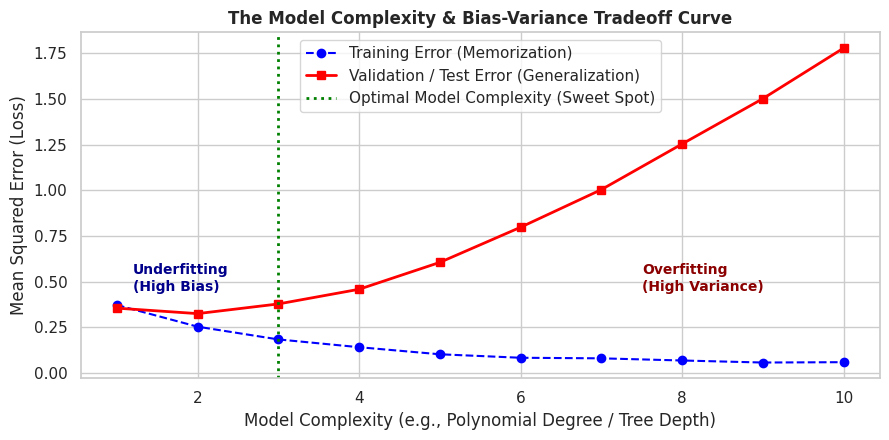

In [ ]:
# ==============================================================================
# SECTION 4: THE BIAS-VARIANCE TRADEOFF & MODEL COMPLEXITY
# ==============================================================================
"""
BIAS-VARIANCE DECOMPOSITION:
Total Error = Bias² + Variance + Irreducible Noise (σ²)

1. UNDERFITTING (High Bias):
   - Model is too simple to capture the underlying pattern.
   - High training error AND high test error.
2. OVERFITTING (High Variance):
   - Model is overly complex; it memorizes training noise instead of the general pattern.
   - Low training error, but high test error.
3. THE SWEET SPOT:
   - Balances model complexity to minimize total generalization error on unseen data.
"""

# Visualizing Model Complexity vs Training & Validation Error
degrees = np.arange(1, 11)
np.random.seed(42)
# Synthetic error curves illustrating the trade-off
train_errors = 0.5 * np.exp(-0.45 * degrees) + 0.05 + np.random.normal(0, 0.005, len(degrees))
val_errors = 0.5 * np.exp(-0.45 * degrees) + 0.04 * (degrees ** 1.65) + np.random.normal(0, 0.01, len(degrees))

plt.figure(figsize=(9, 4.5))
plt.plot(degrees, train_errors, "o--", color="blue", label="Training Error (Memorization)")
plt.plot(degrees, val_errors, "s-", color="red", lw=2, label="Validation / Test Error (Generalization)")
plt.axvline(x=3, color="green", linestyle=":", lw=2, label="Optimal Model Complexity (Sweet Spot)")
plt.text(1.2, 0.45, "Underfitting\n(High Bias)", color="darkblue", fontweight="bold")
plt.text(7.5, 0.45, "Overfitting\n(High Variance)", color="darkred", fontweight="bold")
plt.title("The Model Complexity & Bias-Variance Tradeoff Curve", fontweight="bold")
plt.xlabel("Model Complexity (e.g., Polynomial Degree / Tree Depth)")
plt.ylabel("Mean Squared Error (Loss)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# SECTION 5: LINEAR REGRESSION THEORY, COST FUNCTION & 5 ASSUMPTIONS
# ==============================================================================
"""
MATHEMATICAL FORMULATION:
Simple Regression:   ŷ = w₁x₁ + b
Multiple Regression: ŷ = w₁x₁ + w₂x₂ + ... + w_p x_p + b = Xw + b

1. COST FUNCTION: Mean Squared Error (MSE) / Ordinary Least Squares (OLS)
   J(w, b) = (1 / n) * Σ (y_i - ŷ_i)²

2. GRADIENT DESCENT:
   Iteratively updates parameters in the opposite direction of the gradient:
   w := w - α * ∇_w J(w, b)   (where α is the learning rate)
   Because MSE is a convex quadratic function, gradient descent is guaranteed
   to converge to the global minimum (given a proper learning rate).

3. THE 5 CORE GAUSS-MARKOV ASSUMPTIONS & DIAGNOSTIC CHECKS:
   ┌──────────────────────┬────────────────────────────────┬───────────────────────────┐
   │ Assumption           │ Meaning                        │ How to Check / Diagnose   │
   ├──────────────────────┼────────────────────────────────┼───────────────────────────┤
   │ 1. Linearity         │ Linear relationship between    │ Residuals vs. Fitted plot │
   │                      │ features and target.           │ (should show no curve).   │
   ├──────────────────────┼────────────────────────────────┼───────────────────────────┤
   │ 2. Independence      │ Residuals are independent      │ Durbin-Watson test (~2.0) │
   │                      │ (no autocorrelation).          │ or time-lag scatter.      │
   ├──────────────────────┼────────────────────────────────┼───────────────────────────┤
   │ 3. Homoscedasticity  │ Constant residual variance     │ Residuals vs. Fitted plot │
   │                      │ across all fitted values.      │ (no 'funnel' or 'cone').  │
   ├──────────────────────┼────────────────────────────────┼───────────────────────────┤
   │ 4. Normality of Res. │ Residual errors are normally   │ Q-Q plot & Histogram of   │
   │                      │ distributed (mean = 0).        │ residuals (Shapiro-Wilk). │
   ├──────────────────────┼────────────────────────────────┼───────────────────────────┤
   │ 5. No Multicollinear.│ Features are not highly        │ Variance Inflation Factor │
   │                      │ correlated with each other.    │ (VIF < 5.0).              │
   └──────────────────────┴────────────────────────────────┴───────────────────────────┘
"""

"\nMATHEMATICAL FORMULATION:\nSimple Regression:   ŷ = w₁x₁ + b\nMultiple Regression: ŷ = w₁x₁ + w₂x₂ + ... + w_p x_p + b = Xw + b\n\n1. COST FUNCTION: Mean Squared Error (MSE) / Ordinary Least Squares (OLS)\n   J(w, b) = (1 / n) * Σ (y_i - ŷ_i)²\n\n2. GRADIENT DESCENT:\n   Iteratively updates parameters in the opposite direction of the gradient:\n   w := w - α * ∇_w J(w, b)   (where α is the learning rate)\n   Because MSE is a convex quadratic function, gradient descent is guaranteed \n   to converge to the global minimum (given a proper learning rate).\n\n3. THE 5 CORE GAUSS-MARKOV ASSUMPTIONS & DIAGNOSTIC CHECKS:\n   ┌──────────────────────┬────────────────────────────────┬───────────────────────────┐\n   │ Assumption           │ Meaning                        │ How to Check / Diagnose   │\n   ├──────────────────────┼────────────────────────────────┼───────────────────────────┤\n   │ 1. Linearity         │ Linear relationship between    │ Residuals vs. Fitted plot │\n   │           

In [ ]:
# ==============================================================================
# SECTION 6: REGRESSION EVALUATION METRICS
# ==============================================================================
"""
EVALUATION METRIC EQUATIONS & USAGE:

1. Mean Absolute Error (MAE):
   MAE = (1 / n) * Σ |y_i - ŷ_i|
   - Represents the average absolute error in original target units.
   - Robust to outliers.

2. Mean Squared Error (MSE):
   MSE = (1 / n) * Σ (y_i - ŷ_i)²
   - Penalizes large errors heavily due to squaring.

3. Root Mean Squared Error (RMSE):
   RMSE = √[ (1 / n) * Σ (y_i - ŷ_i)² ]
   - Returns MSE to original target units.
   - PREFERRED OVER MAE when large prediction errors are disproportionately costly.

4. Coefficient of Determination (R²):
   R² = 1 - [ SS_res / SS_tot ] = 1 - [ Σ(y_i - ŷ_i)² / Σ(y_i - ȳ)² ]
   - Proportion of variance in target explained by the model (Scale: -∞ to 1.0; 1.0 = perfect).

5. Adjusted R²:
   Adj R² = 1 - [ (1 - R²)(n - 1) / (n - p - 1) ]   (where p = number of features)
   - Penalizes adding irrelevant features that artificially inflate raw R².
"""

'\nEVALUATION METRIC EQUATIONS & USAGE:\n\n1. Mean Absolute Error (MAE):\n   MAE = (1 / n) * Σ |y_i - ŷ_i|\n   - Represents the average absolute error in original target units.\n   - Robust to outliers.\n\n2. Mean Squared Error (MSE):\n   MSE = (1 / n) * Σ (y_i - ŷ_i)²\n   - Penalizes large errors heavily due to squaring.\n\n3. Root Mean Squared Error (RMSE):\n   RMSE = √[ (1 / n) * Σ (y_i - ŷ_i)² ]\n   - Returns MSE to original target units.\n   - PREFERRED OVER MAE when large prediction errors are disproportionately costly.\n\n4. Coefficient of Determination (R²):\n   R² = 1 - [ SS_res / SS_tot ] = 1 - [ Σ(y_i - ŷ_i)² / Σ(y_i - ȳ)² ]\n   - Proportion of variance in target explained by the model (Scale: -∞ to 1.0; 1.0 = perfect).\n\n5. Adjusted R²:\n   Adj R² = 1 - [ (1 - R²)(n - 1) / (n - p - 1) ]   (where p = number of features)\n   - Penalizes adding irrelevant features that artificially inflate raw R².\n'

=== TRAINED MODEL PARAMETERS ===
Intercept (b): -0.5529
Coefficient (w) for Median_Income  : +0.5462
Coefficient (w) for House_Age      : +0.0168
Coefficient (w) for Avg_Rooms      : -0.2239
Coefficient (w) for Avg_Bedrooms   : +1.1155
Coefficient (w) for Population     : +0.0000
Coefficient (w) for Avg_Occupancy  : -0.0046

=== HOLDOUT TEST EVALUATION METRICS ===
MAE:         $57,921.41  (in actual USD)
MSE:         0.6422
RMSE:        $80,136.59  (in actual USD)
R² Score:    0.5099  (50.99% variance explained)
Adjusted R²: 0.5092


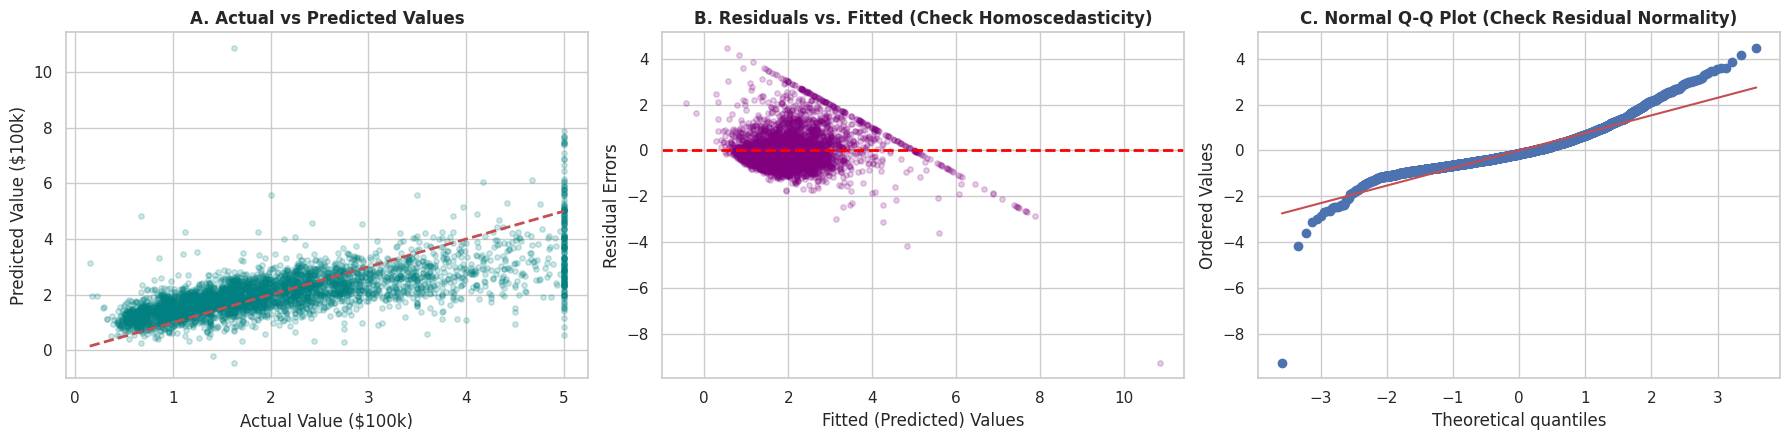

In [ ]:
# ==============================================================================
# SECTION 7: LIVE DEMO — END-TO-END SCIKIT-LEARN REGRESSION & RESIDUAL DIAGNOSTICS
# ==============================================================================
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Feature Selection & Train/Test Split
feature_cols = ["Median_Income", "House_Age", "Avg_Rooms", "Avg_Bedrooms", "Population", "Avg_Occupancy"]
X = housing_df[feature_cols]
y = housing_df["Median_House_Value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Fit Multiple Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 3. Model Parameters
print("=== TRAINED MODEL PARAMETERS ===")
print(f"Intercept (b): {lr_model.intercept_:.4f}")
for feature, coef in zip(feature_cols, lr_model.coef_):
    print(f"Coefficient (w) for {feature:15s}: {coef:+.4f}")

# 4. Generate Predictions & Calculate Residuals
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)
residuals = y_test - y_test_pred

# 5. Compute All 5 Core Evaluation Metrics
n_test = len(y_test)
p_features = X_test.shape[1]

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
adj_r2 = 1 - ((1 - r2) * (n_test - 1) / (n_test - p_features - 1))

print("\n=== HOLDOUT TEST EVALUATION METRICS ===")
print(f"MAE:         ${mae * 100_000:,.2f}  (in actual USD)")
print(f"MSE:         {mse:.4f}")
print(f"RMSE:        ${rmse * 100_000:,.2f}  (in actual USD)")
print(f"R² Score:    {r2:.4f}  ({r2*100:.2f}% variance explained)")
print(f"Adjusted R²: {adj_r2:.4f}")

# 6. Residual Diagnostic Plots (Validating Assumptions)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Plot A: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.2, color="teal", s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_title("A. Actual vs Predicted Values", fontweight="bold")
axes[0].set_xlabel("Actual Value ($100k)")
axes[0].set_ylabel("Predicted Value ($100k)")

# Plot B: Residuals vs Fitted (Checking Linearity & Homoscedasticity)
axes[1].scatter(y_test_pred, residuals, alpha=0.2, color="purple", s=15)
axes[1].axhline(y=0, color="red", linestyle="--", lw=2)
axes[1].set_title("B. Residuals vs. Fitted (Check Homoscedasticity)", fontweight="bold")
axes[1].set_xlabel("Fitted (Predicted) Values")
axes[1].set_ylabel("Residual Errors")

# Plot C: Normal Q-Q Plot (Checking Residual Normality)
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("C. Normal Q-Q Plot (Check Residual Normality)", fontweight="bold")

plt.tight_layout()
plt.show()

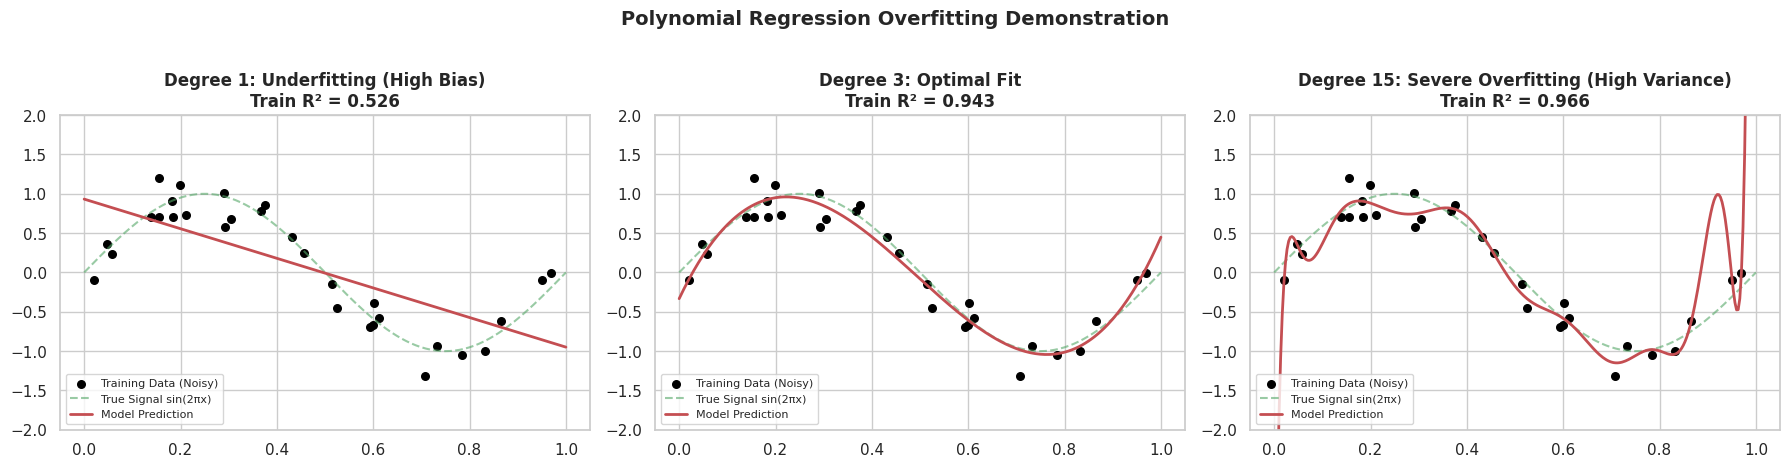

In [ ]:
# ==============================================================================
# SECTION 8: LIVE DEMO — DELIBERATE OVERFITTING WITH POLYNOMIAL REGRESSION
# ==============================================================================
# We fit a 1D non-linear toy problem with Polynomial Degrees 1, 3, and 15
# to demonstrate how high-degree polynomials oscillate wildly.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Generate non-linear sinusoidal synthetic dataset
np.random.seed(42)
n_pts = 30
X_toy = np.sort(np.random.uniform(0, 1, n_pts))
y_toy = np.sin(2 * np.pi * X_toy) + np.random.normal(0, 0.2, n_pts)

X_toy_plot = np.linspace(0, 1, 300)[:, np.newaxis]
X_toy_mat = X_toy[:, np.newaxis]

# 2. Fit Degrees 1 (Underfit), 3 (Optimal), and 15 (Severe Overfit)
degrees = [1, 3, 15]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, deg in zip(axes, degrees):
    # Pipeline: Generate Polynomial Features -> Fit Linear Regression
    poly_model = make_pipeline(PolynomialFeatures(degree=deg), LinearRegression())
    poly_model.fit(X_toy_mat, y_toy)

    y_plot_pred = poly_model.predict(X_toy_plot)
    y_train_pred_toy = poly_model.predict(X_toy_mat)

    train_r2 = r2_score(y_toy, y_train_pred_toy)

    # Plotting
    ax.scatter(X_toy, y_toy, color="black", s=30, label="Training Data (Noisy)")
    ax.plot(X_toy_plot, np.sin(2 * np.pi * X_toy_plot), "g--", alpha=0.6, label="True Signal sin(2πx)")
    ax.plot(X_toy_plot, y_plot_pred, "r-", lw=2, label=f"Model Prediction")
    ax.set_ylim(-2.0, 2.0)

    title_label = "Underfitting (High Bias)" if deg == 1 else ("Optimal Fit" if deg == 3 else "Severe Overfitting (High Variance)")
    ax.set_title(f"Degree {deg}: {title_label}\nTrain R² = {train_r2:.3f}", fontweight="bold")
    ax.legend(fontsize=8, loc="lower left")

plt.suptitle("Polynomial Regression Overfitting Demonstration", fontsize=14, y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# SECTION 9: STUDENT PRACTICE LAB (HOUSING DATASET REGRESSION)
# ==============================================================================
"""
STUDENT LAB ASSIGNMENT:
Task: Build a multiple linear regression model predicting `Median_House_Value`
using 4 specific features: `Median_Income`, `House_Age`, `Avg_Rooms`, and `Avg_Occupancy`.

MANDATORY TASKS:
1. Split `housing_df` into 80% train and 20% test sets (random_state = 42).
2. Train a Scikit-Learn `LinearRegression` model.
3. Compute and display all 4 core metrics on the test set:
   - MAE
   - MSE
   - RMSE
   - R² Score
4. Check the Multicollinearity Assumption by computing the correlation matrix of predictors.
"""

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------

# 1. Define feature matrix and target

# 2. Train/Test Split


# 3. Fit Linear Regression Model

# 4. Predict

# 5. Compute Metrics
